# the Federalist Paper data from [the Project Gutenberg](https://www.gutenberg.org/)

https://pypi.org/project/Gutenberg/

In [1]:
import pandas as pd
import numpy as np
import os
import nltk, re, pprint
from nltk import word_tokenize
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
%matplotlib inline

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>


## 0. Prepare Data

* Import the Data formatted through R
* Preprocess the dataset: define the stop words, tokenize the text

In [2]:
"""
# gutenberg does not work that I manually downloaded the .txt file from the page
file_path = '/Users/sowonjeong/txt-analysis/federalist.txt'

with open(file_path, 'r', encoding='utf-8') as file:
    federalist = file.read()

# Remove unwanted characters and whitespace
text = re.sub(r'\s+', ' ', federalist)

tokens = word_tokenize(text)

tokens = [word.lower() for word in tokens]
tokens = [word for word in tokens if word.isalpha()]

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
tokens = [word for word in tokens if not word in stop_words]
"""

"\n# gutenberg does not work that I manually downloaded the .txt file from the page\nfile_path = '/Users/sowonjeong/txt-analysis/federalist.txt'\n\nwith open(file_path, 'r', encoding='utf-8') as file:\n    federalist = file.read()\n\n# Remove unwanted characters and whitespace\ntext = re.sub(r'\\s+', ' ', federalist)\n\ntokens = word_tokenize(text)\n\ntokens = [word.lower() for word in tokens]\ntokens = [word for word in tokens if word.isalpha()]\n\nnltk.download('stopwords')\n\nstop_words = set(stopwords.words('english'))\ntokens = [word for word in tokens if not word in stop_words]\n"

In [5]:
import json
with open("federalist.json") as f:
    federalist_dict = json.load(f)

In [6]:
federalist_dict[0]['paper']

['To the People of the State of New York:\n\nAfter an unequivocal experience of the inefficacy of the subsisting federal government, you are called upon to deliberate on a new Constitution for the United States of America. The subject speaks its own importance; comprehending in its consequences nothing less than the existence of the UNION, the safety and welfare of the parts of which it is composed, the fate of an empire in many respects the most interesting in the world. It has been frequently remarked that it seems to have been reserved to the people of this country, by their conduct and example, to decide the important question, whether societies of men are really capable or not of establishing good government from reflection and choice, or whether they are forever destined to depend for their political constitutions on accident and force. If there be any truth in the remark, the crisis at which we are arrived may with propriety be regarded as the era in which that decision is to be

authorship source: https://guides.loc.gov/federalist-papers/full-text

In [7]:
import pandas as pd

# Initialize an empty list to store the flattened data
flattened_data = []

# Iterate over each dictionary in the list
for item in federalist_dict:
    # Extract metadata and content
    meta = item['meta'][0]  # Assuming there's only one meta per item
    paper = item['paper'][0] if item['paper'] else ''  # Assuming content is a list

    # Flatten the data
    flattened_data.append({
        'meta_number': meta.get('number', ''),
        'meta_author': meta.get('author', ''),
        'meta_title': meta.get('title', ''),
        'meta_journal': meta.get('journal', ''),
        'meta_body': paper
    })

# Create a DataFrame
df = pd.DataFrame(flattened_data)
federalist_df = df.drop(df.index[69])

In [8]:
import numpy as np
federalist_df.index = np.arange(85)

In [9]:
from nltk.tokenize import sent_tokenize, word_tokenize
federalist_df['meta_sentence'] = federalist_df['meta_body'].apply(sent_tokenize)
federalist_df['meta_words'] = federalist_df['meta_sentence'].apply(lambda sentences: [word_tokenize(sentence) for sentence in sentences])


In [13]:
import warnings
import pandas as pd
from nltk.tokenize import word_tokenize

# Suppress specific FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Assuming federalist_df is defined and has the required columns

# Create a list to store sentence-level data
sentence_data = []

# Iterate over each row in the original DataFrame
for index, row in federalist_df.iterrows():
    for i, sentence in enumerate(row['meta_sentence']):
        # Count the number of words in the sentence
        word_count = len(word_tokenize(sentence))

        # Append the data to the sentence_data list
        sentence_data.append({'meta_number': row['meta_number'],
                              'meta_author': row['meta_author'],
                              'meta_sentence_number': i + 1,
                              'meta_sentence': sentence,
                              'meta_num_of_words': word_count})

# Convert the list of dictionaries to a DataFrame
sentence_df = pd.DataFrame(sentence_data)

sentence_df


,meta_number,meta_author,meta_sentence_number,meta_sentence,meta_num_of_words
0,1,HAMILTON,1,To the People of the State of New York:\n\nAft...,40
1,1,HAMILTON,2,The subject speaks its own importance; compreh...,48
2,1,HAMILTON,3,It has been frequently remarked that it seems ...,66
3,1,HAMILTON,4,"If there be any truth in the remark, the crisi...",60
4,1,HAMILTON,5,This idea will add the inducements of philanth...,29
...,...,...,...,...,...
5733,85,HAMILTON,74,I dread the more the consequences of new attem...,36
5734,85,HAMILTON,75,PUBLIUS.,2
5735,85,HAMILTON,76,[1] Entitled “An Address to the People of the ...,43
5736,85,HAMILTON,77,"[3] Hume’s _Essays_, vol.",10


In [14]:
np.max(sentence_df['meta_num_of_words'])

307

In [9]:
# Group by 'meta_author' and calculate the mean of 'number_of_words' for each author
sentence_df.groupby('meta_author')['meta_num_of_words'].mean()

meta_author
HAMILTON                37.537037
HAMILTON AND MADISON    30.331776
HAMILTON OR MADISON     34.101911
JAY                     43.333333
MADISON                 37.011925
Name: meta_num_of_words, dtype: float64

In [10]:
sentence_df.groupby(['meta_author', 'meta_number']).size()#.group_by(level='meta_author').mean()

meta_author  meta_number
HAMILTON     1              49
             6              74
             7              85
             8              73
             9              64
                            ..
MADISON      44             76
             45             57
             46             77
             47             87
             48             57
Length: 85, dtype: int64

In [235]:
sentence_df

,meta_number,meta_author,meta_sentence_number,meta_sentence,meta_num_of_words
0,1,HAMILTON,1,To the People of the State of New York:\n\nAft...,40
1,1,HAMILTON,2,The subject speaks its own importance; compreh...,48
2,1,HAMILTON,3,It has been frequently remarked that it seems ...,66
3,1,HAMILTON,4,"If there be any truth in the remark, the crisi...",60
4,1,HAMILTON,5,This idea will add the inducements of philanth...,29
...,...,...,...,...,...
5732,85,HAMILTON,74,I dread the more the consequences of new attem...,36
5733,85,HAMILTON,75,PUBLIUS.,2
5734,85,HAMILTON,76,[1] Entitled “An Address to the People of the ...,43
5735,85,HAMILTON,77,"[3] Hume’s _Essays_, vol.",10


In [237]:
# Load the regular expression library
import re
# Remove punctuation
word_df['meta_word'] = \
word_df['meta_sentence'].map(lambda x: re.sub('[,\.!?]', '', x))
# Convert the titles to lowercase
word_df['meta_word'] = \
word_df['meta_word'].map(lambda x: x.lower())
word_df['meta_word'].head()

0    to the people of the state of new york:\n\naft...
1    the subject speaks its own importance; compreh...
2    it has been frequently remarked that it seems ...
3    if there be any truth in the remark the crisis...
4    this idea will add the inducements of philanth...
Name: meta_word, dtype: object

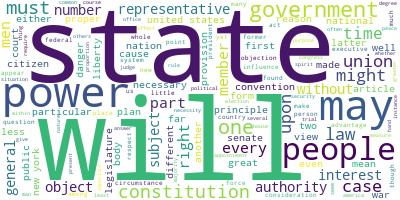

In [241]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ','.join(list(word_df['meta_word'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=5, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

In [246]:
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
        
data = word_df['meta_word'].values.tolist()
list(sent_to_words(data))

[['to',
  'the',
  'people',
  'of',
  'the',
  'state',
  'of',
  'new',
  'york',
  'after',
  'an',
  'unequivocal',
  'experience',
  'of',
  'the',
  'inefficacy',
  'of',
  'the',
  'subsisting',
  'federal',
  'government',
  'you',
  'are',
  'called',
  'upon',
  'to',
  'deliberate',
  'on',
  'new',
  'constitution',
  'for',
  'the',
  'united',
  'states',
  'of',
  'america'],
 ['the',
  'subject',
  'speaks',
  'its',
  'own',
  'importance',
  'comprehending',
  'in',
  'its',
  'consequences',
  'nothing',
  'less',
  'than',
  'the',
  'existence',
  'of',
  'the',
  'union',
  'the',
  'safety',
  'and',
  'welfare',
  'of',
  'the',
  'parts',
  'of',
  'which',
  'it',
  'is',
  'composed',
  'the',
  'fate',
  'of',
  'an',
  'empire',
  'in',
  'many',
  'respects',
  'the',
  'most',
  'interesting',
  'in',
  'the',
  'world'],
 ['it',
  'has',
  'been',
  'frequently',
  'remarked',
  'that',
  'it',
  'seems',
  'to',
  'have',
  'been',
  'reserved',
  'to',

## 1. Molletser and Wallace(1964)

Define the function words used for the original study. Refer to the TABLE 2.5 in Mollester and Wallace(1963)

In [11]:
function_words = ['a','all','also','an','and','any','are',
                 'as','at','be','been','but','by','can',
                 'do','down','even','every','for','from','had',
                 'has','have','her','his','if','in','into',
                  'is','it','its','may','more','must','my',
                  'no','not','now','of','on','one','only',
                  'or','our','shall','should','so','some','such',
                  'than','that','the','their','then','there','thing',
                  'this','to','up','upon','was','were','what',
                  'when','which','who','will','with','would','your']
len(function_words)

70

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

In [13]:
# Count Vectorizer
vect = CountVectorizer(stop_words="english")  
vects = vect.fit_transform(federalist_df['meta_body'])

# Select the first five rows from the data set
td = pd.DataFrame(vects.todense())  
td.columns = vect.get_feature_names_out()
term_document_matrix = td.T
term_document_matrix.columns = ['Doc '+str(i) for i in range(1, 86)]
term_document_matrix['total_count'] = term_document_matrix.sum(axis=1)

# Top 25 words 
term_document_matrix = term_document_matrix.sort_values(by ='total_count',ascending=False)[:25] 

# Print the first 10 rows 
print(term_document_matrix.drop(columns=['total_count']).head(10))

              Doc 1  Doc 2  Doc 3  Doc 4  Doc 5  Doc 6  Doc 7  Doc 8  Doc 9  \
states            2      2     11      1      1      7     31     10     12   
government        9      9     16     16      2      2      2      3     17   
state             6      1      8      6      2      6      8      7      7   
people            6     23      8      8      3      4      1      9      3   
power             2      1      3      2      1      4      2      5      3   
constitution      8      0      0      0      0      1      1      4      3   
union             7      8      3      4      7      0      5      2      6   
national          1      3     14      7      0      4      2      2      2   
new               7      3      2      1      1      2     11      2      7   
federal           1      2      2      0      0      0      3      0      2   

              Doc 10  ...  Doc 76  Doc 77  Doc 78  Doc 79  Doc 80  Doc 81  \
states             3  ...       4       3       2    

<AxesSubplot: >

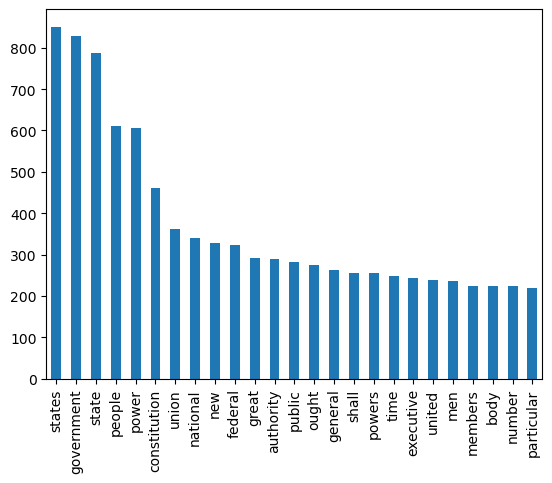

In [14]:
term_document_matrix['total_count'].plot.bar()

/Users/sowonjeong/opt/anaconda3/lib/python3.9/site-packages/pandas/plotting/_matplotlib/core.py:1114: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<AxesSubplot: xlabel='state', ylabel='government'>

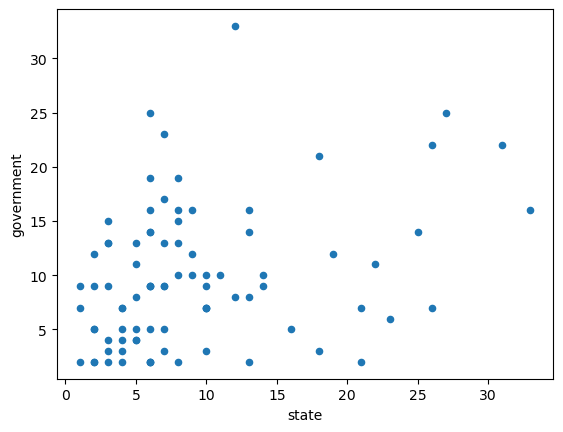

In [15]:
term_document_matrix.drop(columns=['total_count']).T.plot.scatter(x='state', y='government')

In [16]:
# Activate math
import math

# Define a cosine similarity function
def cosine_similarity(a,b):
    "compute cosine similarity of v1 to v2: (a dot b)/{||a||*||b||)"
    sumxx, sumxy, sumyy = 0, 0, 0
    for i in range(len(a)):
        x = a[i]; y = b[i]
        sumxx += x*x
        sumyy += y*y
        sumxy += x*y
    return sumxy/math.sqrt(sumxx*sumyy)

# Activate numpy
import numpy as np 

# Save the similarity index between the documents
def pair(s):
    for i, v1 in enumerate(s):
        for j in range(i, len(s)):
            yield [v1, s[j]]
            
def all_pair(s):
    for i, v1 in enumerate(s):
        for j, v2 in enumerate(s):
            yield [v1, v2]

dic={} 
for (a,b) in list(all_pair(['Doc '+str(i) for i in range(1, 86)])):
  dic[(a,b)] = cosine_similarity(term_document_matrix[a].tolist(), term_document_matrix[b].tolist())

In [17]:
documents= ['Doc '+str(i) for i in range(1, 86)]
final_df = pd.DataFrame(np.asarray([[(dic[(x,y)] if (x,y) in dic else 0) for y in documents] for x in documents]))
final_df.columns =  documents
final_df.index = documents 

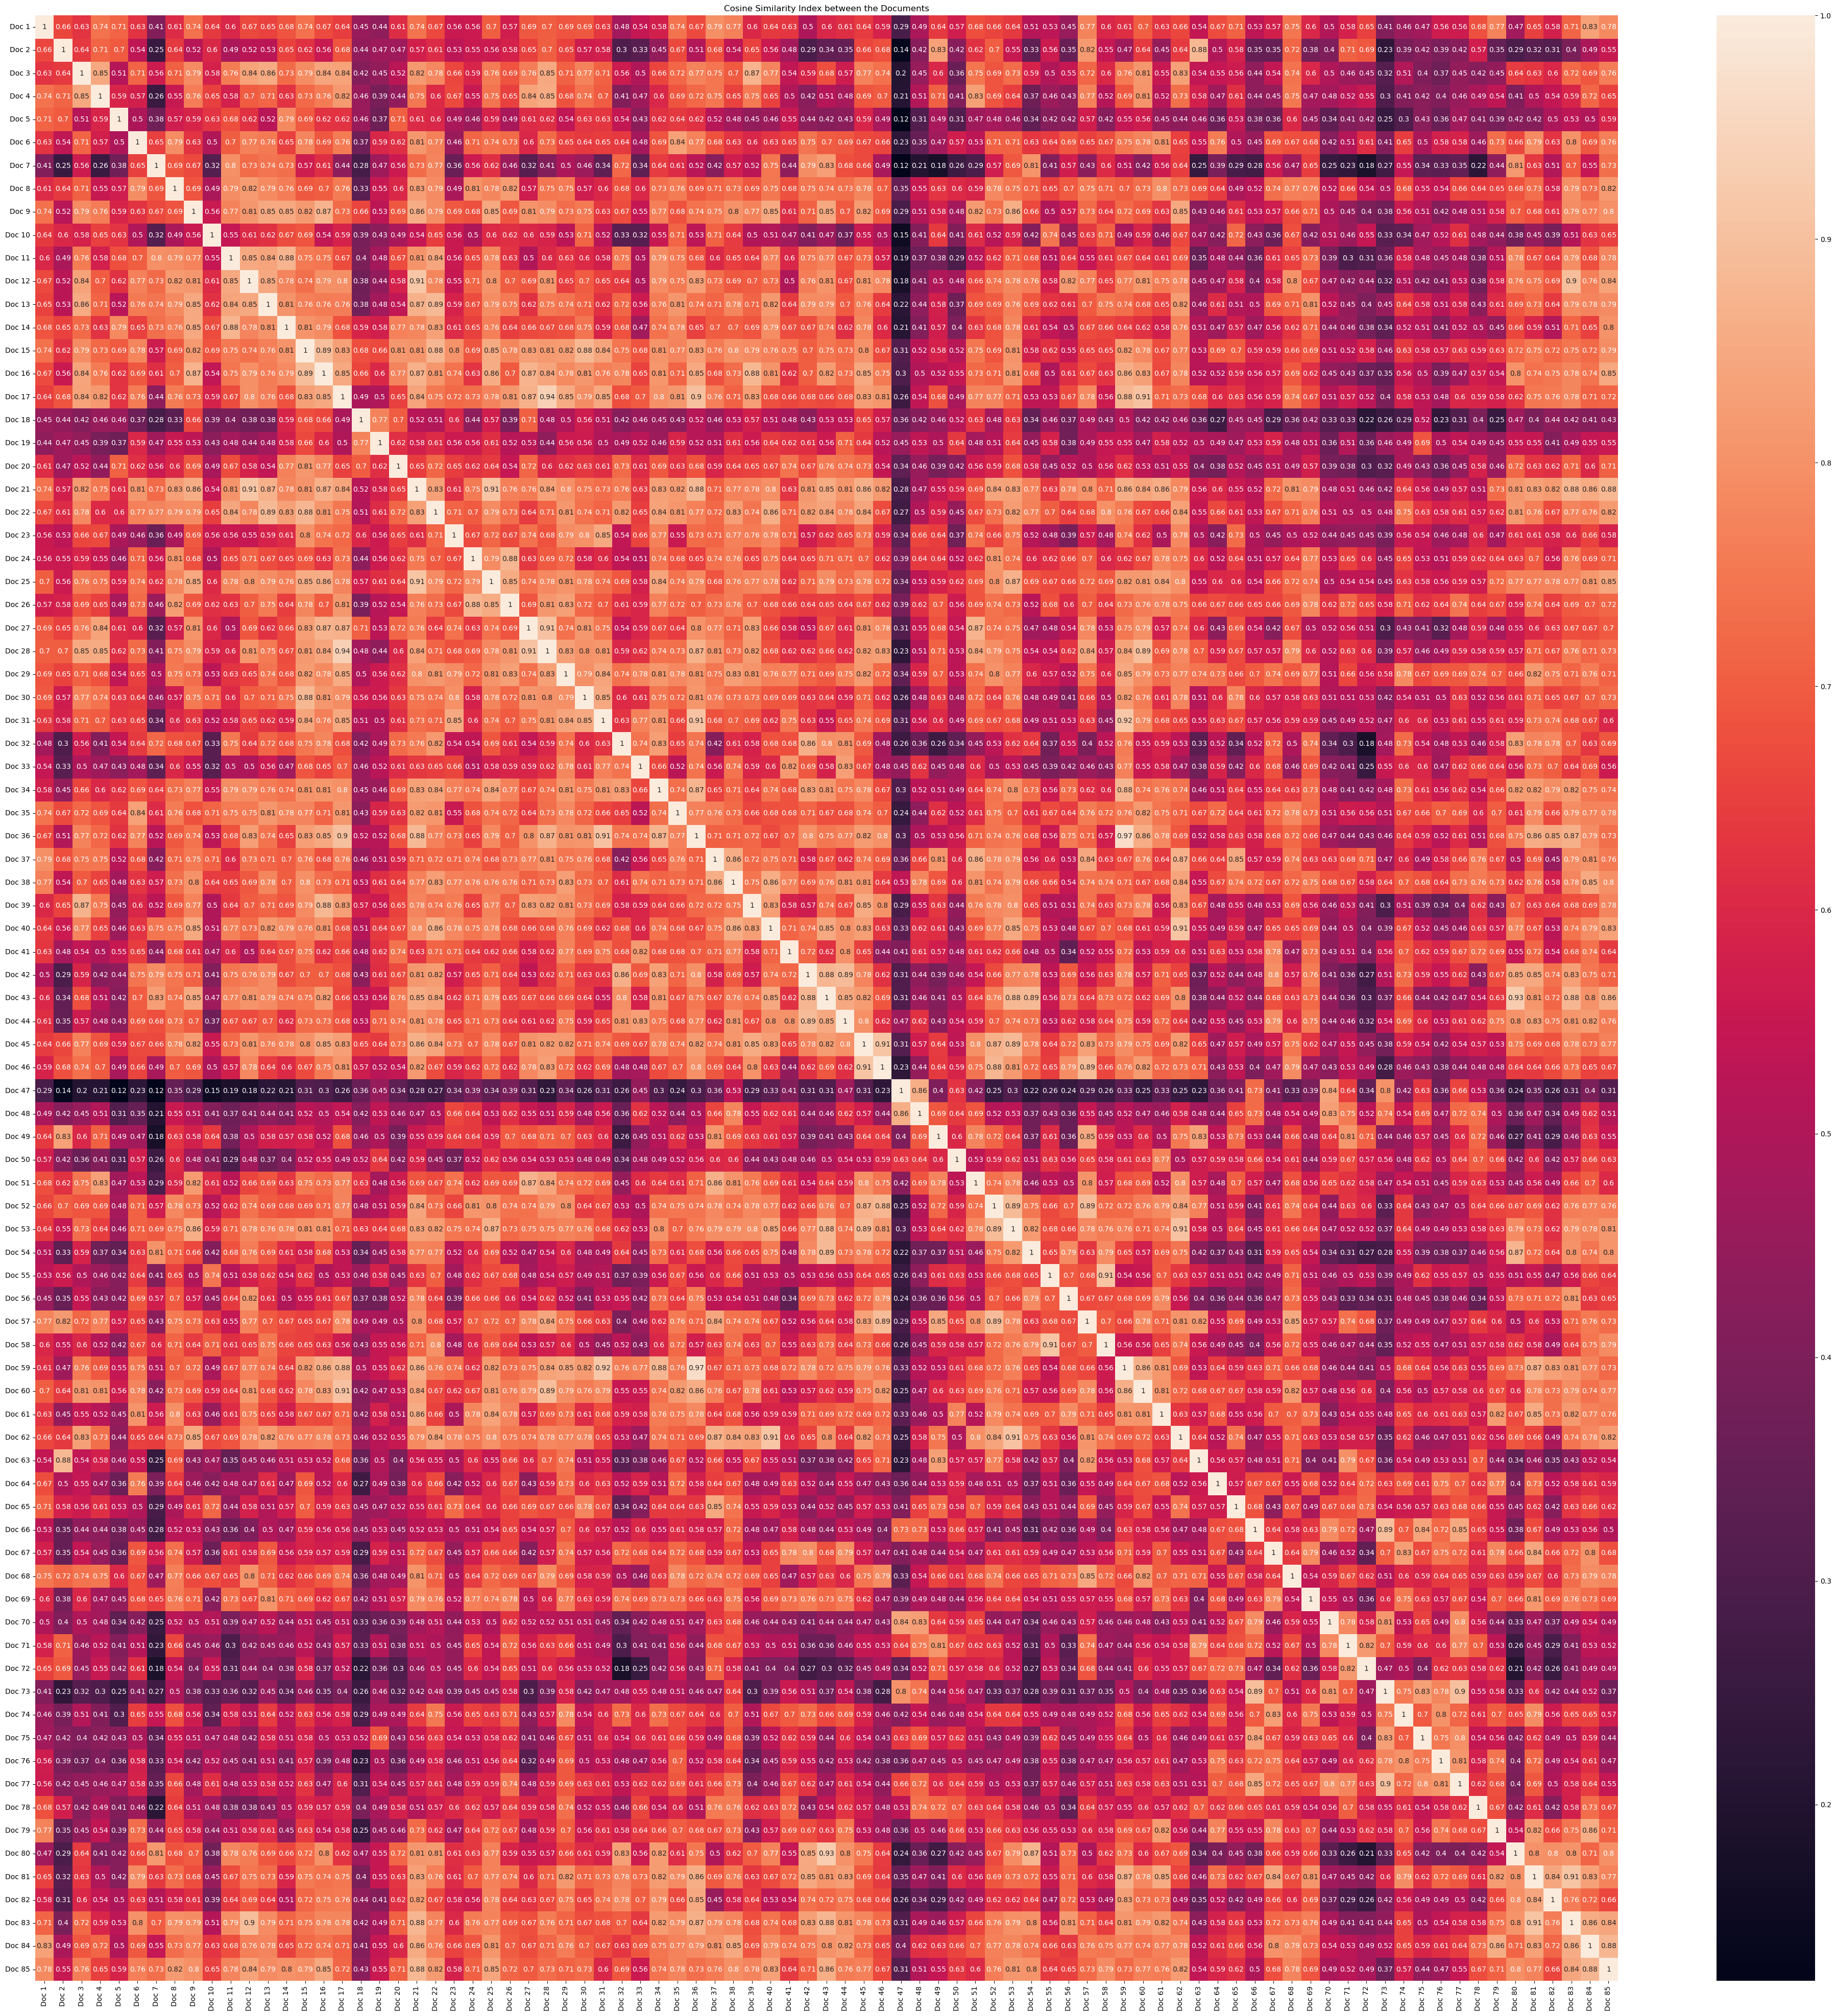

In [18]:
import seaborn as sns
plt.figure(figsize = (50,50))
ax = sns.heatmap(final_df, annot = True)
ax.set_title('Cosine Similarity Index between the Documents')
plt.show()

In [19]:
pd.DataFrame([final_df[final_df<1.0].max(), final_df[final_df<1.0].idxmax(), final_df.min(),final_df.idxmin()], 
                     index=['max_value', 'max_column', 'min_value', 'min_column']).T

,max_value,max_column,min_value,min_column
Doc 1,0.834718,Doc 84,0.291472,Doc 47
Doc 2,0.881605,Doc 63,0.135488,Doc 47
Doc 3,0.872686,Doc 39,0.204111,Doc 47
Doc 4,0.854421,Doc 28,0.210075,Doc 47
Doc 5,0.786801,Doc 14,0.1211,Doc 47
...,...,...,...,...
Doc 81,0.908275,Doc 83,0.320289,Doc 2
Doc 82,0.851004,Doc 36,0.257698,Doc 72
Doc 83,0.908275,Doc 81,0.305874,Doc 47
Doc 84,0.876838,Doc 85,0.397247,Doc 47


## 2. Latent Semantic Analysis

In [191]:
# Convert the text into tf_idf values
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer

# Convert the text into tf_idf values
# stop_list = ['the','and','of','to','in','it','which','is','be','that','then','or','his', 'he', 'would','her','they','our','as','will','by','with','you','my','not','this','are','your', 'their', 'for', 'than', 'may', 'an', 'from', 'its', 'have', 'at', 'from', 'if', 'them', 'we', 'on', 'upon', 'an', 'been', 'were', 'us','those', 'who', 'was', 'has', 'she', 'there', 'has', 'can', 'could', 'had', 'but']
vec = CountVectorizer(lowercase=True,
                        #stop_words='english',
                        ngram_range = (1,1))
tf_idf_vec = vec.fit_transform(federalist_df['meta_body'])

In [192]:
vec.get_feature_names_out()

array(['000', '10', '11', ..., 'zeal', 'zealand', 'zealous'], dtype=object)

In [193]:
# Convert the tf_idf matrix into a data frame with labels
tf_idf_df = pd.DataFrame(columns=vec.get_feature_names_out(), data=tf_idf_vec.toarray())

In [194]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Access the list of English stop words
stop_words_list = list(ENGLISH_STOP_WORDS)

add_author = ['meta_number','meta_author']
ftn_words_columns = [col for col in function_words if col in tf_idf_df.columns] #+ add_author
#ftn_words_columns = ftn_words_columns.extend(add_author)
stop_words_columns = [col for col in stop_words_list if col in tf_idf_df.columns] #+ add_author
#stop_words_columns = stop_words_columns.extend(add_author)
no_stop_words_columns = [col for col in tf_idf_df.columns if col not in stop_words_list]#.remove(add_author)

In [195]:
# Combine the original data set with the tf_idf dataframe
cluster_df = federalist_df.join(tf_idf_df)

In [196]:
# These are our final data sets.  y is author, X contains the text data
y_set = cluster_df['meta_author']

In [197]:
exclude_columns = ['meta_title','meta_journal','meta_body','meta_sentence','meta_words']
selected_columns = [col for col in cluster_df.columns if col not in exclude_columns]
X_set = cluster_df[selected_columns]

In [198]:
X_set

,meta_number,meta_author,000,10,11,128,13,136,13th,1648,...,yokes,york,you,young,your,yourselves,zaleucus,zeal,zealand,zealous
0,1,HAMILTON,0,0,0,0,0,0,0,0,...,0,1,7,0,10,0,0,3,0,0
1,2,JAY,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,3,JAY,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,4,JAY,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
4,5,JAY,0,0,0,0,0,0,0,0,...,0,1,1,1,3,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,81,HAMILTON,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
81,82,HAMILTON,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
82,83,HAMILTON,0,0,0,0,0,0,0,0,...,0,5,0,0,0,0,0,0,0,0
83,84,HAMILTON,0,0,0,0,0,1,0,0,...,0,3,0,0,0,0,0,2,0,0


I refer to this resources for the code: https://github.com/matthewzhou/FederalistPapers/blob/master/federalist.ipynb

In [200]:
# Naive way to graph a cluster is just reduce the dimensions to 2 with svd
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=5)
#svd.fit(X_set[ftn_words_columns])
svd.fit(X_set[no_stop_words_columns])


svd_plotdata = []
authors = X_set['meta_author'].unique()

for author in authors:
    #svd_plotdata[i].append(svd.transform(X_set.loc[X_set['meta_author'] == author, ftn_words_columns]))
    svd_plotdata.append(svd.transform(X_set.loc[X_set['meta_author'] == author, no_stop_words_columns]))
        

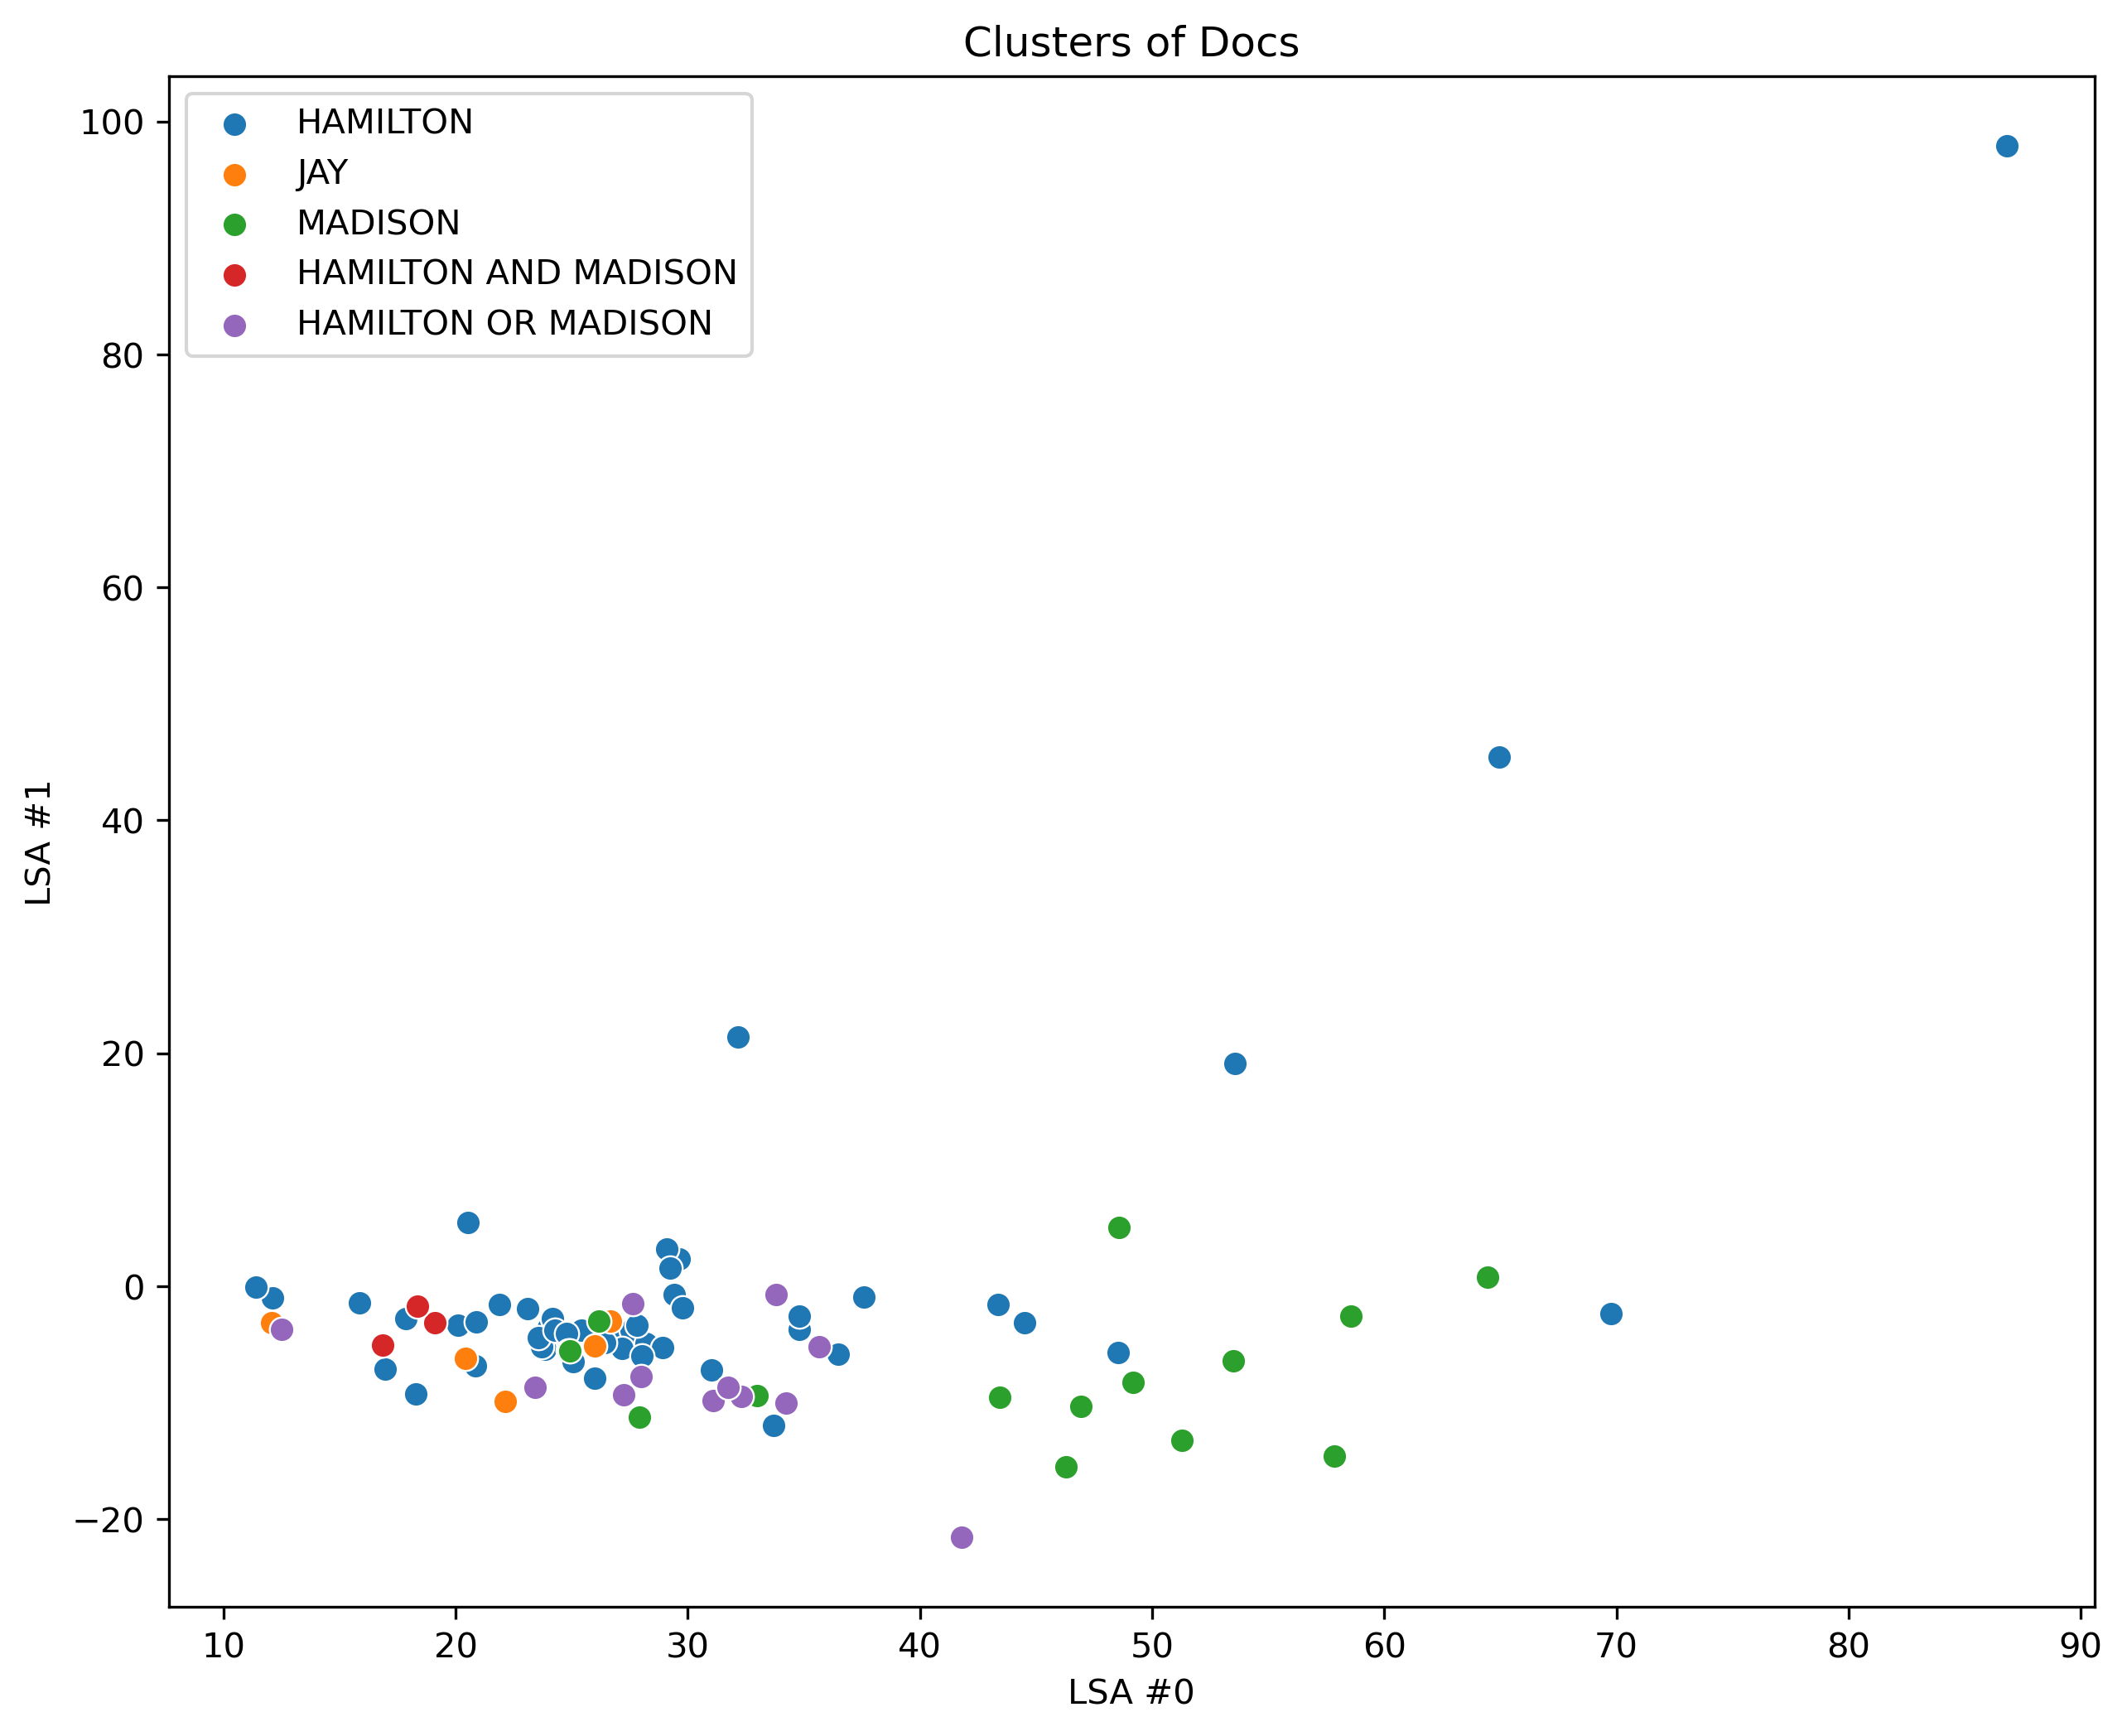

In [201]:
# Graph the results on a 2D plane
import matplotlib.pyplot as plt
import random
import seaborn as sns

%matplotlib inline

#plt.figure(figsize=(100,100))
plt.figure(figsize=(10,8), dpi=300)
plt.ylabel('LSA #1')
plt.xlabel('LSA #0')
#plt.ylim(ymin=-1, ymax=1)
plt.title('Clusters of Docs')

# Colormap
colormap = sns.color_palette("tab10", len(svd_plotdata))  # You can choose other palettes like "hsv", "viridis", "plasma", etc.

ci = 0
# Plotting each cluster
for i, plotdata in enumerate(svd_plotdata):
    sns.scatterplot(x=plotdata[:, 0], y=plotdata[:, 1], color=colormap[i], 
                    label=authors[i], s = 50)

# Display the legend
plt.legend()


plt.show()

In [41]:
vocabulary = vec.vocabulary_
feature_names = vec.get_feature_names_out() 
print("Number of unique words considered: " + str(len(feature_names)))
feature_names[50:60]

Number of unique words considered: 8382


array(['abbe', 'abbé', 'abetted', 'abhorrence', 'abilities', 'ability',
       'abject', 'able', 'ablest', 'abolish'], dtype=object)

In [42]:
dense = tf_idf_vec.todense()
paper = dense[0].tolist()[0]
phrase_scores = [pair for pair in zip(range(0, len(paper)), paper) if pair[1] > 0]
print("Sample word vectors with td-idf score:")
sorted(phrase_scores, key=lambda t: t[1] * -1)[:5]

Sample word vectors with td-idf score:


[(517, 0.17252268305821603),
 (4882, 0.12120281210935777),
 (3599, 0.11307619632743364),
 (1676, 0.1116229786839739),
 (2697, 0.10945109930400047)]

In [43]:
federalist_df['meta_author'].value_counts(sort=False)


HAMILTON                51
JAY                      5
MADISON                 14
HAMILTON AND MADISON     3
HAMILTON OR MADISON     12
Name: meta_author, dtype: int64

In [44]:
federalist_df.loc[federalist_df['meta_author'] == 'JAY',:]

,meta_number,meta_author,meta_title,meta_journal,meta_body,meta_sentence,meta_words
1,2,JAY,Concerning Dangers from Foreign Force and Infl...,Independent Journal.,To the People of the State of New York:\n\nWhe...,[To the People of the State of New York:\n\nWh...,"[[To, the, People, of, the, State, of, New, Yo..."
2,3,JAY,The Same Subject Continued (Concerning Dangers...,Independent Journal.,To the People of the State of New York:\n\nIt ...,[To the People of the State of New York:\n\nIt...,"[[To, the, People, of, the, State, of, New, Yo..."
3,4,JAY,The Same Subject Continued (Concerning Dangers...,Independent Journal.,To the People of the State of New York:\n\nMy ...,[To the People of the State of New York:\n\nMy...,"[[To, the, People, of, the, State, of, New, Yo..."
4,5,JAY,The Same Subject Continued (Concerning Dangers...,Independent Journal.,To the People of the State of New York:\n\nQue...,[To the People of the State of New York:\n\nQu...,"[[To, the, People, of, the, State, of, New, Yo..."
63,64,JAY,The Powers of the Senate,New York Packet.,To the People of the State of New York:\n\nIt ...,[To the People of the State of New York:\n\nIt...,"[[To, the, People, of, the, State, of, New, Yo..."


In [45]:
count = 0
tfscores = []
ham = []
jay = []
mad = []
ham_mad = []
unknown = []

for i in dense:
    paper = i.tolist()[0]
    phrase_scores = [pair for pair in zip(range(0, len(paper)), paper) if pair[1] > 0]
    sorted_phrase_scores = sorted(phrase_scores, key=lambda t: t[1] * -1)
    print("\n Paper " + str(count+1) + "         | " + str(federalist_df.loc[count].meta_author) + "\n")
    count += 1
    counter = 0
    for phrase, score in [(feature_names[word_id], score) for (word_id, score) in sorted_phrase_scores][:10]:
        print('{0: <20} {1}'.format(phrase, score))
        if federalist_df.loc[counter].meta_author == 'HAMILTON':
            ham.append(phrase)
        elif federalist_df.loc[counter].meta_author == 'JAY':
            jay.append(phrase)
        elif federalist_df.loc[counter].meta_author == 'MADISON':
            mad.append(phrase)
        elif federalist_df.loc[counter].meta_author == 'HAMILTON AND MADISON':
            ham_mad.append(phrase)
        elif federalist_df.loc[counter].meta_author == 'HAMILTON OR MADISON':
            unknown.append(phrase)
        if counter == 0:
            tfscores.append(score)
        counter += 1


 Paper 1         | HAMILTON

appearance           0.17252268305821603
men                  0.12120281210935777
government           0.11307619632743364
constitution         0.1116229786839739
efficiency           0.10945109930400047
good                 0.10908190113758774
shall                0.10731792347427276
union                0.10605246059568804
truth                0.10491948651332665
liberty              0.1021270219402377

 Paper 2         | JAY

people               0.2516156077620512
providence           0.15625986010265014
recommended          0.1425292021697319
congress             0.13713597122140558
convention           0.13498186567032977
america              0.12284746816520557
union                0.105534329561633
farewell             0.10417324006843341
tried                0.10031100436659335
confederacies        0.0996088632814981

 Paper 3         | JAY

national             0.21190555375500447
government           0.1869428528473382
causes               0.172

In [46]:
print("Most common words for Madison")
Counter(mad).most_common()[:10]

Most common words for Madison


[('citizens', 3),
 ('union', 3),
 ('rule', 2),
 ('state', 2),
 ('necessary', 2),
 ('causes', 2),
 ('liberty', 1),
 ('confederacies', 1),
 ('temptations', 1),
 ('trade', 1)]

In [47]:
print("Most common words for Hamilton")
Counter(ham).most_common()[:10]

Most common words for Hamilton


[('states', 17),
 ('state', 12),
 ('government', 12),
 ('power', 7),
 ('constitution', 7),
 ('union', 6),
 ('people', 6),
 ('powers', 6),
 ('senate', 6),
 ('national', 5)]

In [48]:
print("Most common words for Collaborated Work")
Counter(ham_mad).most_common()[:10]

Most common words for Collaborated Work


[]

## 3. Latent Dirichlet Allocation(LDA)

In [49]:
import os
import pandas as pd
from time import time
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [460]:
# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')
# Vectorize document using TF-IDF
tfidf = TfidfVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (2,2),
                        tokenizer = tokenizer.tokenize)
# Fit and Transform the documents
train_data = tfidf.fit_transform(federalist_df['meta_body'])

In [514]:
# Use tf (raw term count) features for LDA.
print("Extracting tf features for LDA...")
tf_vectorizer = CountVectorizer(
    lowercase = True,
    # max_df=0.95, min_df=2, 
    max_features=2000, 
    stop_words="english",
    ngram_range = (2,2)
)
t0 = time()
tf = tf_vectorizer.fit_transform(federalist_df['meta_body'])
print("done in %0.3fs." % (time() - t0))
print()

Extracting tf features for LDA...
done in 0.278s.



In [515]:
tf.shape

(85, 2000)

In [516]:
# Define the number of topics or components
num_components=10
# Create LDA object
lda=LatentDirichletAllocation(n_components=num_components)
# Fit and Transform SVD model on data
lda_matrix = lda.fit_transform(tf)
# Get Components 
lda_components=lda.components_

In [517]:
# Print the topics with their terms
terms = tfidf.get_feature_names_out()
for index, component in enumerate(lda_components):
    zipped = zip(terms, component)
    top_terms_key=sorted(zipped, key = lambda t: t[1], reverse=True)[:5]
    top_terms_list=list(dict(top_terms_key).keys())
    print("Topic "+str(index)+": ",top_terms_list)

Topic 0:  ['affected delays', 'additional shield', 'affects question', 'achaeans threw', 'abb 300']
Topic 1:  ['addition establishments', 'additional shield', 'actors pernicious', 'affects question', 'administration agreed']
Topic 2:  ['affects question', 'affect local', 'additional shield', 'administration agreed', 'adversaries new']
Topic 3:  ['additional shield', 'addition immense', 'actual insurrections', 'added artifice', 'according best']
Topic 4:  ['affects question', 'additional shield', 'achaeans threw', 'admiralty certain', 'acting authority']
Topic 5:  ['acts assembly', 'accessible touch', 'acts act', 'acceptance congress', 'act opinion']
Topic 6:  ['according best', 'affects question', 'adversaries constitution', 'adversaries ground', 'admittance enemy']
Topic 7:  ['affects question', 'affairs individual', 'additional shield', 'adventured limits', 'addition establishments']
Topic 8:  ['acquiesce necessity', 'additional shield', 'administration agreed', 'adoption entire', 'a

In [518]:

def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

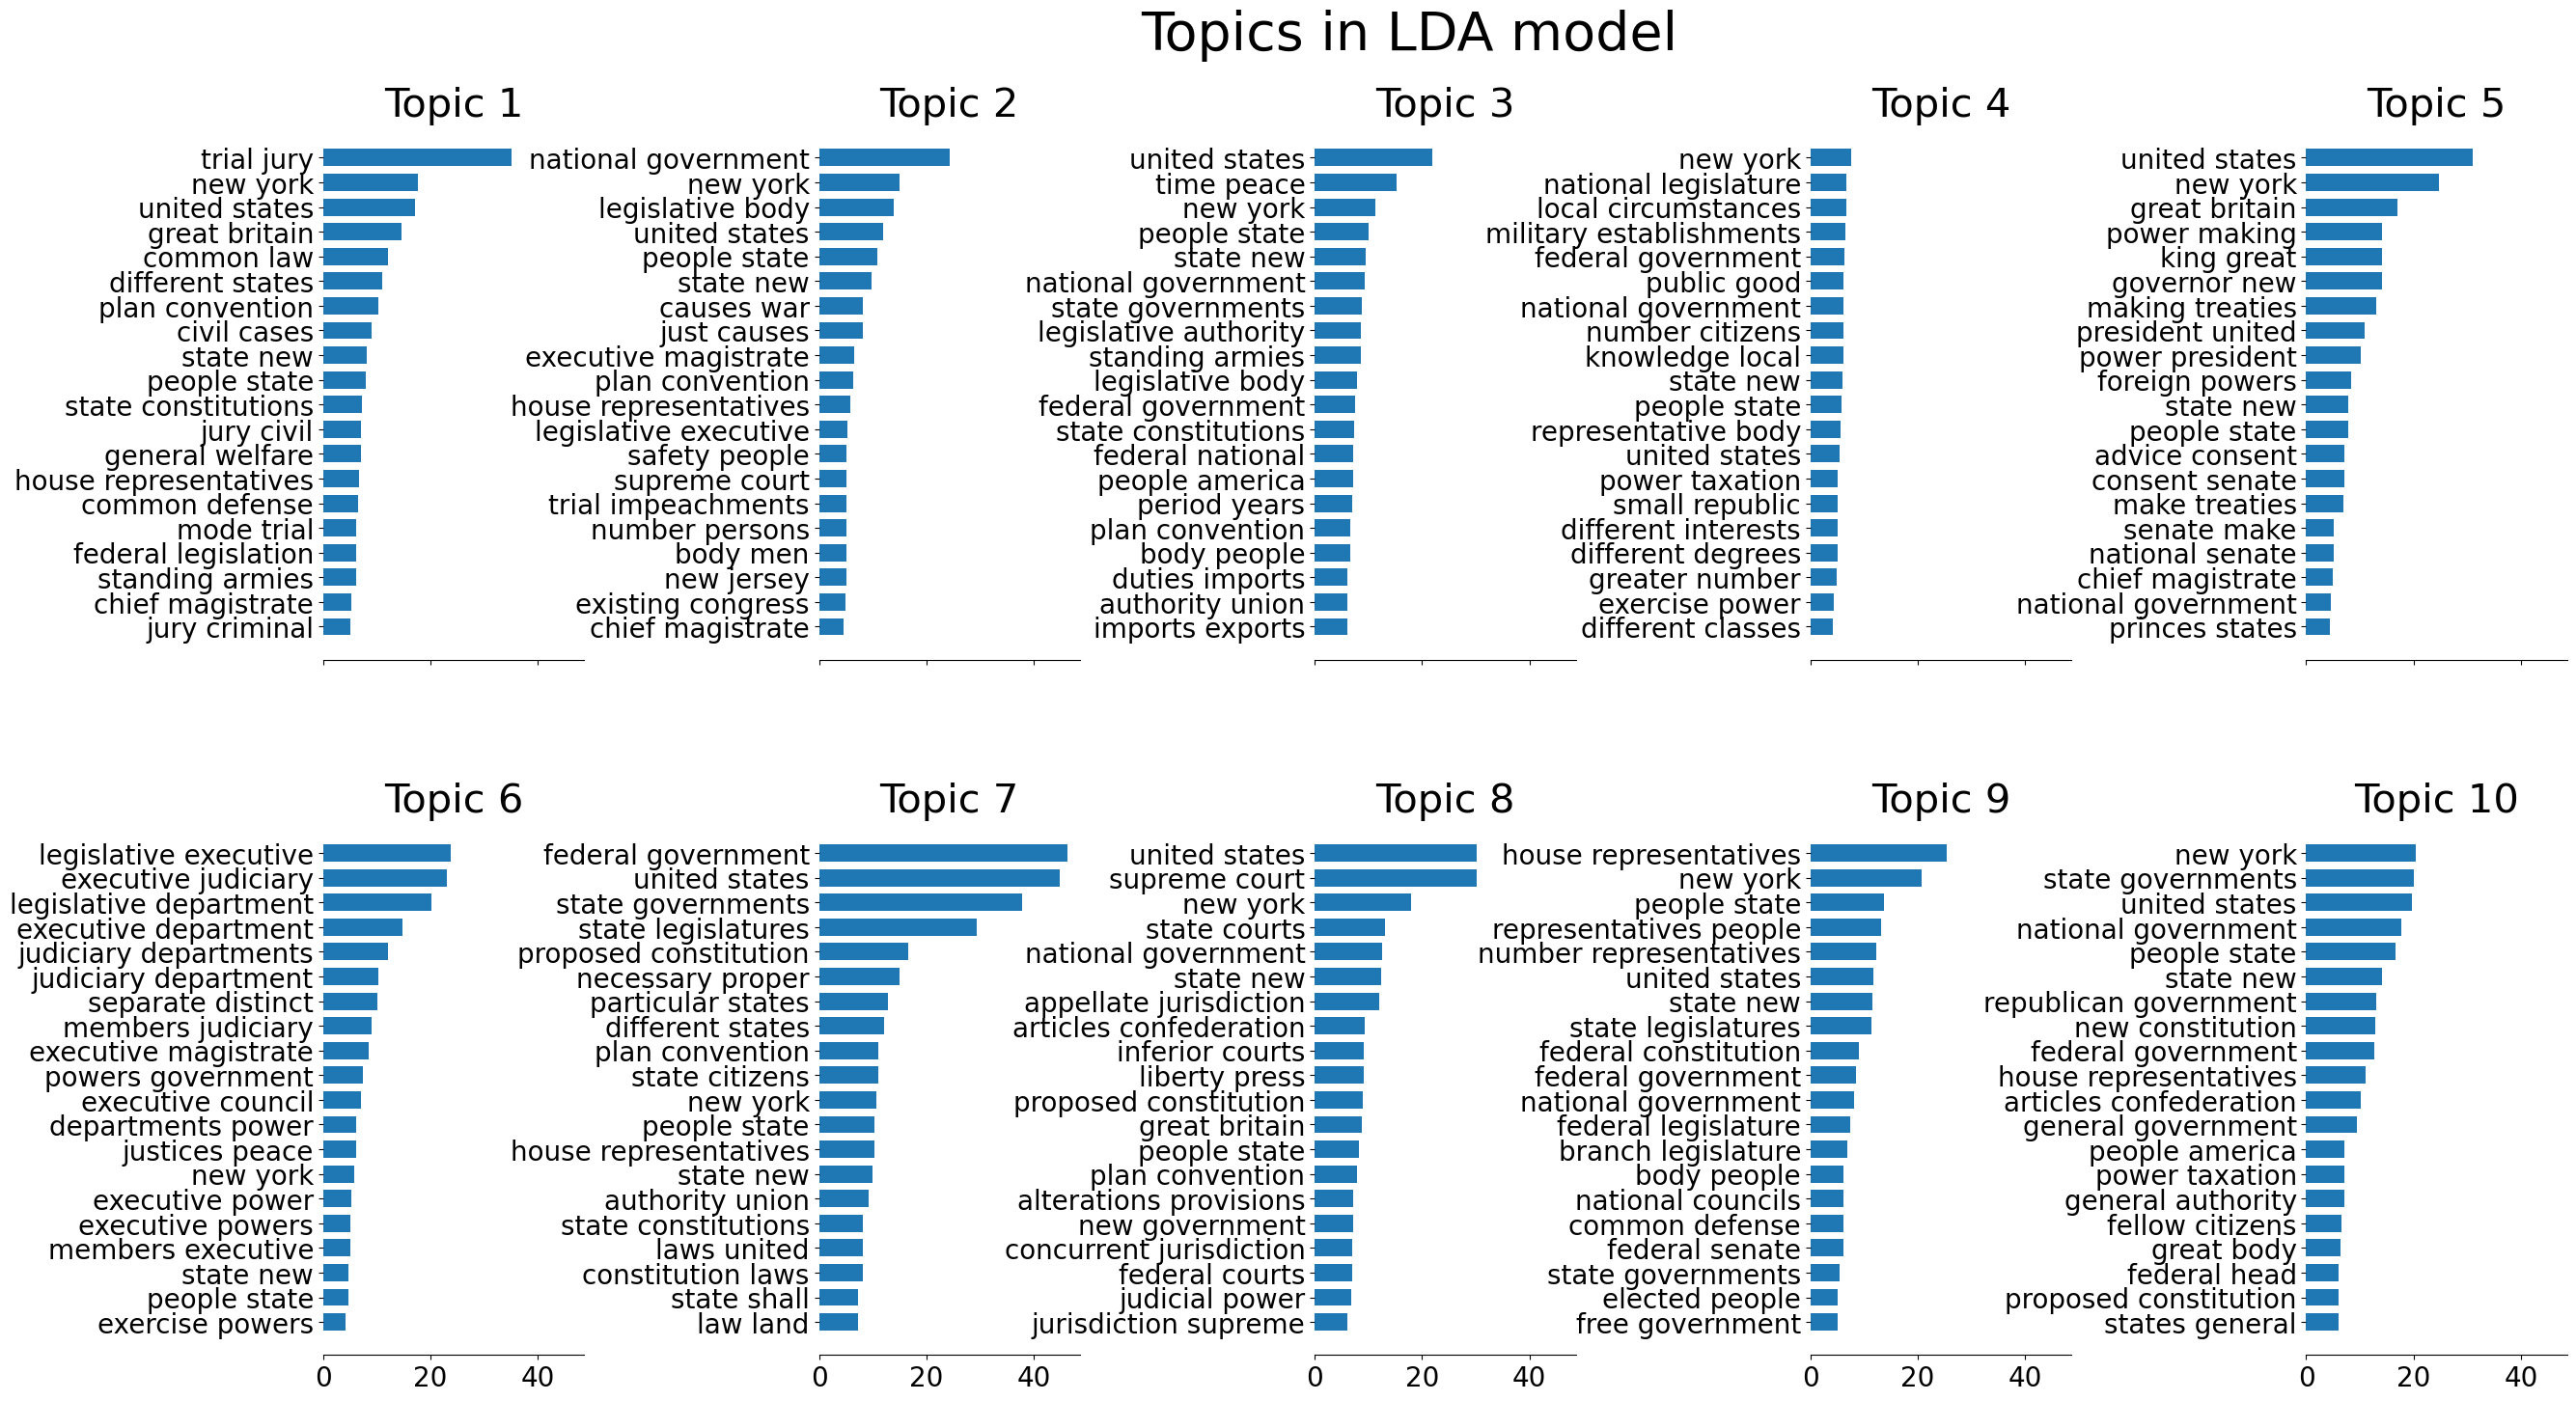

In [519]:
tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, 20, "Topics in LDA model")

In [531]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import LdaModel

# Assuming you have a fitted LDA model
lda_model = LdaModel(corpus, num_topics=10, id2word=dictionary, passes=15)

# Number of topics
num_topics = 10

# Generate word clouds for each topic
for i in range(num_topics):
    plt.figure()

    # Extract words and their weights
    wc = WordCloud(background_color='white')
    wc.fit_words(dict(lda_model.show_topic(i, 200)))

    # Display word cloud
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {i}")
    plt.show()
lda.components_.shape

(10, 2000)

In [ ]:
from wordcloud import WordCloud
wordcloud = WorldCloud.generate()

In [520]:
doc_topic = lda.transform(tf)
doc_topic.shape

(85, 10)

In [521]:
#for n in range(doc_topic.shape[0]):
#    topic_most_pr = doc_topic[n].argmax()
#    print("doc: {} topic: {}\n".format(n,topic_most_pr))

In [522]:
doc_topic[1].sum()

1.0000000000000002

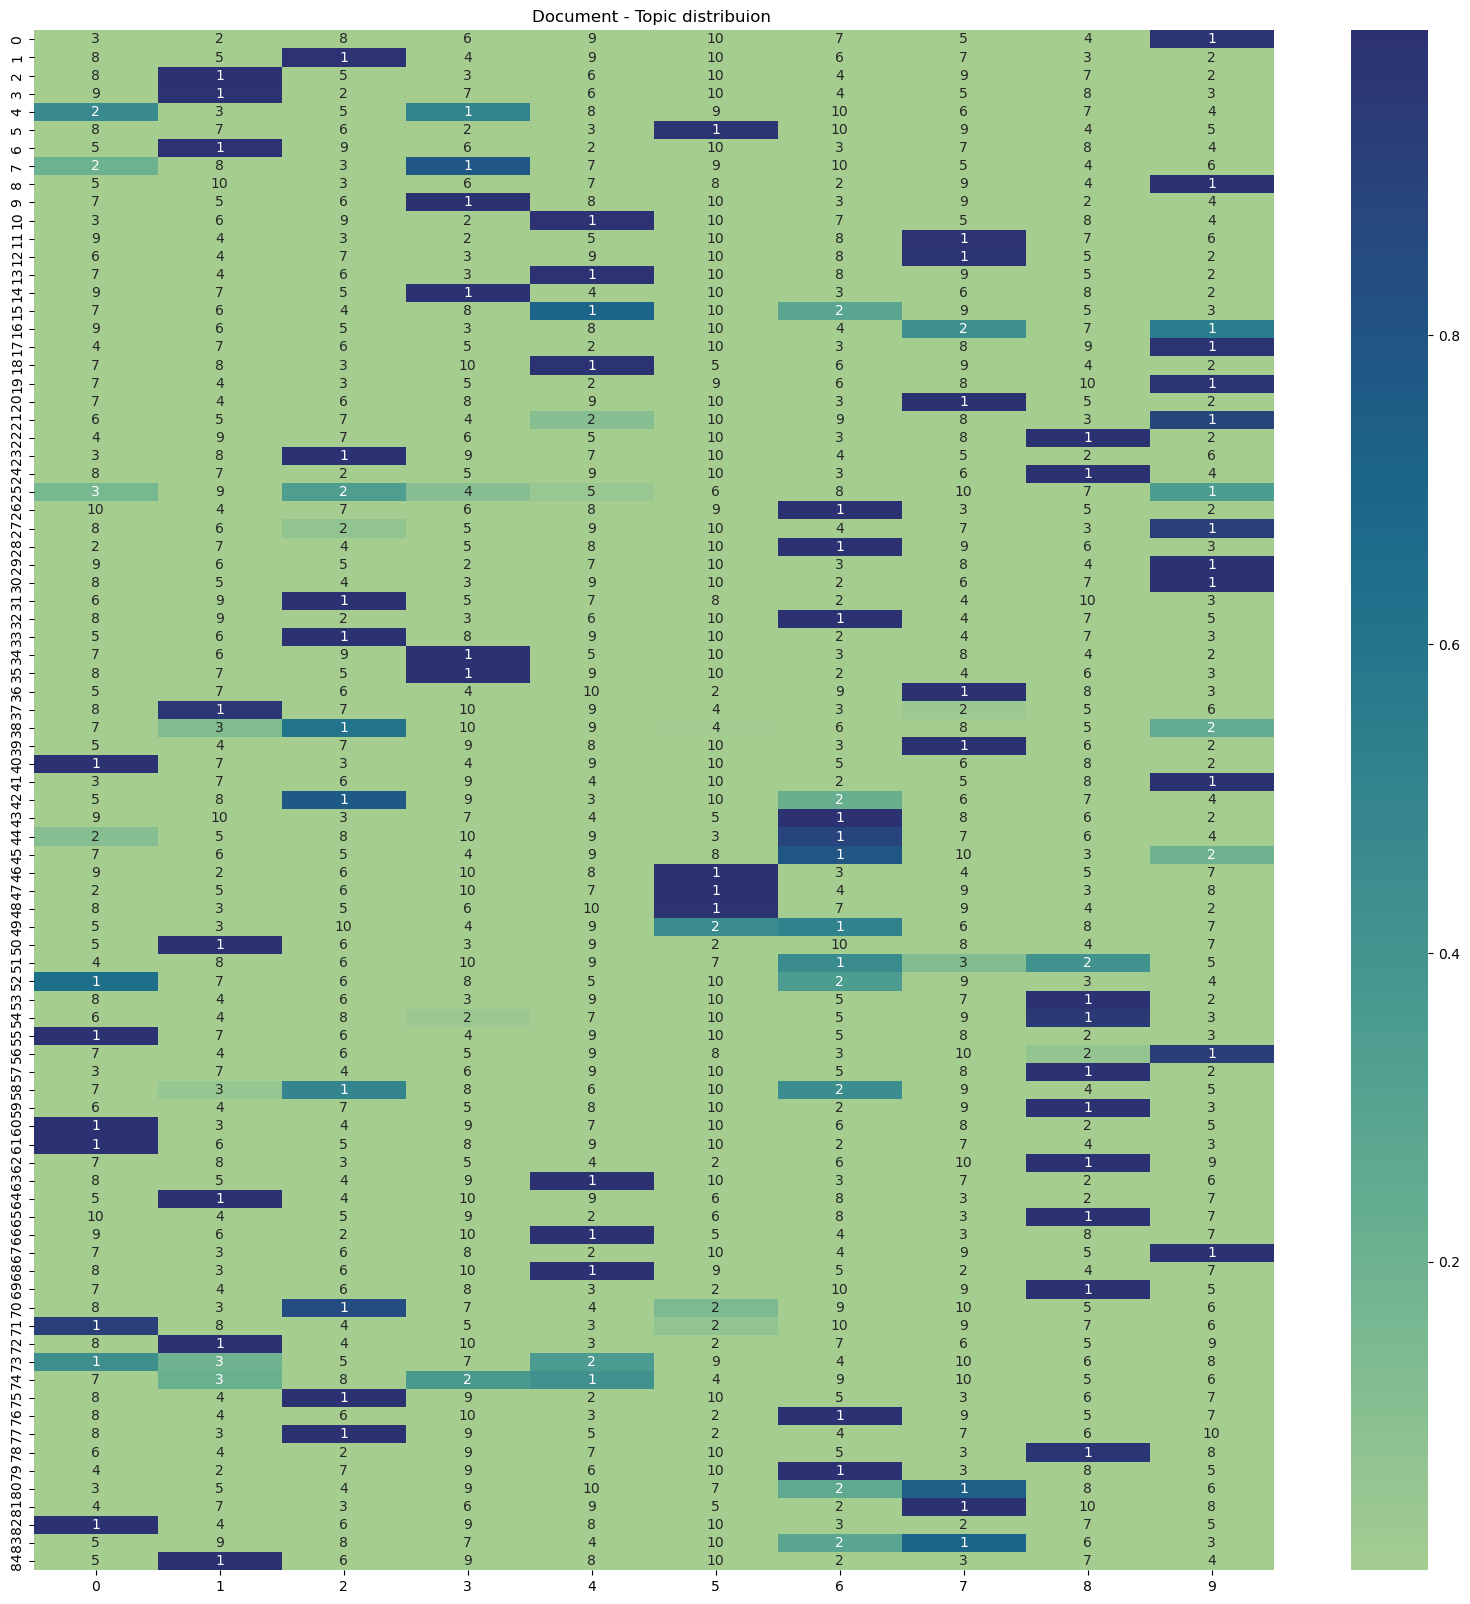

In [523]:
import seaborn as sns
documents= ['Doc '+str(i) for i in range(1, 86)]
doc_topic_df = pd.DataFrame(doc_topic)
doc_topic_df .columns =  ['Topic '+str(i) for i in range(1, 11)]
doc_topic_df .index = documents 
plt.figure(figsize = (20,20))
ax = sns.heatmap(doc_topic,  annot=doc_topic_df.rank(axis="columns", ascending=False), cmap = 'crest') 
# rank 1 has the highes probability
ax.set_title('Document - Topic distribuion ')
plt.show()

In [524]:
lda.components_.shape # topic word distribution

(10, 2000)

In [525]:
lda.doc_topic_prior_ # alpha

0.1

In [526]:
lda.topic_word_prior_ # alpha

0.1

In [527]:
doc_topic.shape

(85, 10)

what if we use the doc-topic as latent variable in dimension = # topics.

In [528]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X_train, y_train = doc_topic[federalist_df['meta_author'] != 'HAMILTON OR MADISON'], federalist_df['meta_author'][federalist_df['meta_author'] != 'HAMILTON OR MADISON']
X_test = doc_topic[federalist_df['meta_author'] == 'HAMILTON OR MADISON']

X_train_before_lda = tf[federalist_df['meta_author'] != 'HAMILTON OR MADISON']
X_test_before_lda = tf[federalist_df['meta_author'] == 'HAMILTON OR MADISON']

# Create and train the SVM model
kernel_for_svm ='sigmoid'
svm_model = SVC(kernel=kernel_for_svm)  
svm_model.fit(X_train, y_train)
svm_model_before_lda = SVC(kernel = kernel_for_svm).fit(X_train_before_lda, y_train)

# Predictions and evaluation
y_pred = svm_model.predict(X_test)
y_pred_before_lda = svm_model_before_lda.predict(X_test_before_lda)
print(y_pred)
print(y_pred_before_lda)

['HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON'
 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON']
['HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON'
 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON']


In [529]:
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train)
clf_before_lda = LinearDiscriminantAnalysis().fit(X_train_before_lda.toarray(), y_train)
# LinearDiscriminantAnalysis()
print(clf.predict(X_test))
print(clf_before_lda.predict(X_test_before_lda.toarray()))

['MADISON' 'MADISON' 'JAY' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON'
 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON']
['HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON'
 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON']


## 4. Partial Least Squares

In [434]:
from sklearn.cross_decomposition import PLSRegression
import pandas as pd

In [452]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

In [453]:
y_train_encoded

array([0, 2, 2, 2, 2, 0, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [454]:
pls_before_lda = PLSRegression(n_components=10)
pls_before_lda.fit(X_train_before_lda.toarray(), y_train_encoded)

PLSRegression(n_components=10)

In [455]:
y_pred_before_lda = pls.predict(X_test_before_lda.toarray())

In [457]:
label_encoder.inverse_transform(np.round(y_pred_before_lda).astype(int))

array(['HAMILTON AND MADISON', 'HAMILTON AND MADISON', 'JAY', 'JAY',
       'JAY', 'HAMILTON AND MADISON', 'HAMILTON AND MADISON',
       'HAMILTON AND MADISON', 'HAMILTON AND MADISON',
       'HAMILTON AND MADISON', 'JAY', 'JAY'], dtype=object)

In [ ]:
pls = PLSRegression(n_components=10)

## 5. Word2Vec/GloVE

### 5-1 Word2Vec: Download the pre-trained model

In [458]:
# importing all necessary modules
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
import warnings

download the pretrained Word2Vec Model from google: https://code.google.com/archive/p/word2vec/

In [459]:
from gensim.models import KeyedVectors

# Load the pre-trained Word2Vec model
model = KeyedVectors.load_word2vec_format('GoogleNews-vectors-negative300.bin', binary=True)

# Now you can use the model

In [61]:
model.similarity('state', 'government')  

0.4580062

In [206]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Assuming df is your DataFrame and it has columns 'meta_author' and 'meta_body'

# Vectorize the text data
vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust the number of max_features
X = vectorizer.fit_transform(federalist_df['meta_body'])

# Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, federalist_df['meta_author'], test_size=0.2, random_state=42)
X_train, y_train = X[federalist_df['meta_author'] != 'HAMILTON OR MADISON'], federalist_df['meta_author'][federalist_df['meta_author'] != 'HAMILTON OR MADISON']
X_test = X[federalist_df['meta_author'] == 'HAMILTON OR MADISON']

# Create and train the SVM model
svm_model = SVC(kernel='linear')  # You can experiment with different kernels
svm_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = svm_model.predict(X_test)
#print(classification_report(y_test, y_pred))

In [204]:
y_pred

array(['HAMILTON', 'HAMILTON', 'HAMILTON', 'HAMILTON', 'HAMILTON',
       'HAMILTON', 'HAMILTON', 'HAMILTON', 'HAMILTON', 'HAMILTON',
       'HAMILTON', 'HAMILTON'], dtype=object)

In [208]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
clf = LinearDiscriminantAnalysis()
clf.fit(X_train.toarray(), y_train)
LinearDiscriminantAnalysis()
print(clf.predict(X_test.toarray()))


['HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON'
 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON' 'HAMILTON']


### 5-2. GloVE: Download the pre-trained model

https://nlp.stanford.edu/projects/glove/

In [ ]:
def load_glove_model(glove_file):
    print("Loading Glove Model")
    with open(glove_file, 'r', encoding="utf-8") as file:
        model = {}
        for line in file:
            split_line = line.split()
            word = split_line[0]
            embedding = np.array([float(val) for val in split_line[1:]])
            model[word] = embedding
        print("Done.", len(model), " words loaded!")
        return model

glove_model = load_glove_model('path/to/glove.txt')


In [ ]:
def document_vector(doc, model):
    # Remove out-of-vocabulary words
    doc = [word for word in doc if word in model]
    if not doc:
        return np.zeros(model[next(iter(model))].shape)
    return np.mean([model[word] for word in doc], axis=0)

# Assuming df['meta_body'] contains the text documents
X = np.array([document_vector(text.split(), glove_model) for text in df['meta_body']])


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, df['meta_author'], test_size=0.2, random_state=42)

# Create the SVM model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))


## 6. Transformer

I'll simply use the model from [the Hugging Face Interface](https://huggingface.co/docs/transformers/installation)

In [ ]:
#!pip install transformers

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
from transformers import pipeline
# pipeline for text classification
classifier = pipeline("sentiment-analysis")

In [ ]:
classifier("Nous sommes très heureux de vous présenter la bibliothèque 🤗 Transformers.")

In [ ]:
results = classifier(["We are very happy to show you the 🤗 Transformers library.", "We hope you don't hate it."])
for result in results:
    print(f"label: {result['label']}, with score: {round(result['score'], 4)}")

In [ ]:
pt_save_directory = "./pt_save_pretrained"
tokenizer.save_pretrained(pt_save_directory)
pt_model.save_pretrained(pt_save_directory)

In [ ]:
from transformers import pipeline

# This model is a `zero-shot-classification` model.
# It will classify text, except you are free to choose any label you might imagine
classifier = pipeline(model="facebook/bart-large-mnli")
classifier(
    "I have a problem with my iphone that needs to be resolved asap!!",
    candidate_labels=["Hamilton", "Jay", "Madison","Hamilton and Madision"]
)